# Crop Yield Prediction — Exploratory Data Analysis (EDA)

## Project
**AI-Powered Crop Yield Prediction and Agricultural Productivity Intelligence Platform**

## Dataset
`Smart_Farming_Crop_Yield_2024.csv`

This notebook performs:
- Dataset overview
- Data quality checks
- Missing-value analysis
- Duplicate checks
- Statistical analysis
- Categorical feature analysis
- Yield distribution
- Crop-wise yield analysis
- Environmental factor vs. yield analysis
- Correlation analysis
- Outlier detection
- Key findings

**Dataset size:** 500 rows × 22 columns.


## 1. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
sns.set_theme(style='whitegrid')


## 2. Load Dataset

In [24]:
# Keep this notebook in the same folder as the CSV.
df = pd.read_csv("Smart_Farming_Crop_Yield_2024.csv")
df.head()


,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,fertilizer_type,pesticide_usage_ml,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,Organic,6.34,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.97,83.00,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,Inorganic,9.60,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.61,70.87,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,Mixed,15.26,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.50,79.07,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,Organic,25.80,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.07,85.52,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,Mixed,25.65,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.57,81.69,0.84,Severe


## 3. Basic Dataset Information

In [25]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Rows: 500
Columns: 22

Column names:
['farm_id', 'region', 'crop_type', 'soil_moisture_%', 'soil_pH', 'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours', 'irrigation_type', 'fertilizer_type', 'pesticide_usage_ml', 'sowing_date', 'harvest_date', 'total_days', 'yield_kg_per_hectare', 'sensor_id', 'timestamp', 'latitude', 'longitude', 'NDVI_index', 'crop_disease_status']

Data types:


,dtype
farm_id,object
region,object
crop_type,object
soil_moisture_%,float64
soil_pH,float64
temperature_C,float64
rainfall_mm,float64
humidity_%,float64
sunlight_hours,float64
irrigation_type,object


In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    object 
 1   region                500 non-null    object 
 2   crop_type             500 non-null    object 
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    object 
 10  fertilizer_type       500 non-null    object 
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    object 
 13  harvest_date          500 non-null    object 
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  5

In [27]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
soil_moisture_%,500.00,26.75,10.15,10.16,17.89,25.86,36.02,44.98
soil_pH,500.00,6.52,0.59,5.51,6.03,6.53,7.04,7.50
temperature_C,500.00,24.68,5.35,15.00,20.30,24.66,29.09,34.84
rainfall_mm,500.00,181.69,72.29,50.17,119.22,191.55,239.03,298.96
humidity_%,500.00,65.19,14.64,40.23,51.86,65.69,77.99,90.00
sunlight_hours,500.00,7.03,1.69,4.01,5.67,7.00,8.47,10.00
pesticide_usage_ml,500.00,26.59,13.20,5.05,14.95,25.98,38.01,49.94
total_days,500.00,119.50,16.80,90.00,105.75,119.00,134.00,150.00
yield_kg_per_hectare,500.00,4032.93,1174.43,2023.56,2994.82,4071.69,5062.11,5998.29
latitude,500.00,22.44,7.28,10.00,16.26,21.98,28.53,34.98


## 4. Missing Values

In [28]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_pct
})
display(missing_table[missing_table["Missing Values"] > 0])


,Missing Values,Missing Percentage
irrigation_type,150,30.00
crop_disease_status,130,26.00


### Missing-value handling

Missing values are present in categorical columns such as `irrigation_type` and `crop_disease_status`.
For EDA, these are represented as **Unknown** so that records are not unnecessarily deleted.


In [29]:
eda_df = df.copy()

for col in ["irrigation_type", "crop_disease_status"]:
    eda_df[col] = eda_df[col].fillna("Unknown")

display(eda_df.isnull().sum().sort_values(ascending=False).head(10))


farm_id                 0
region                  0
NDVI_index              0
longitude               0
latitude                0
timestamp               0
sensor_id               0
yield_kg_per_hectare    0
total_days              0
harvest_date            0
dtype: int64

## 5. Duplicate Records

In [30]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().copy()
    eda_df = df.copy()
    for col in ["irrigation_type", "crop_disease_status"]:
        eda_df[col] = eda_df[col].fillna("Unknown")
    print("Shape after removing duplicates:", df.shape)
else:
    print("No duplicate rows found.")


Duplicate rows: 0
No duplicate rows found.


## 6. Categorical Feature Analysis

In [31]:
categorical_cols = [
    "region", "crop_type", "irrigation_type",
    "fertilizer_type", "crop_disease_status"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(eda_df[col].value_counts(dropna=False).to_frame("count"))



--- region ---


,count
region,
Central USA,109
East Africa,107
North India,99
South USA,94
South India,91



--- crop_type ---


,count
crop_type,
Maize,111
Soybean,108
Cotton,107
Wheat,92
Rice,82



--- irrigation_type ---


,count
irrigation_type,
Unknown,150
Sprinkler,121
Manual,118
Drip,111



--- fertilizer_type ---


,count
fertilizer_type,
Inorganic,167
Mixed,167
Organic,166



--- crop_disease_status ---


,count
crop_disease_status,
Severe,133
Unknown,130
Mild,125
Moderate,112


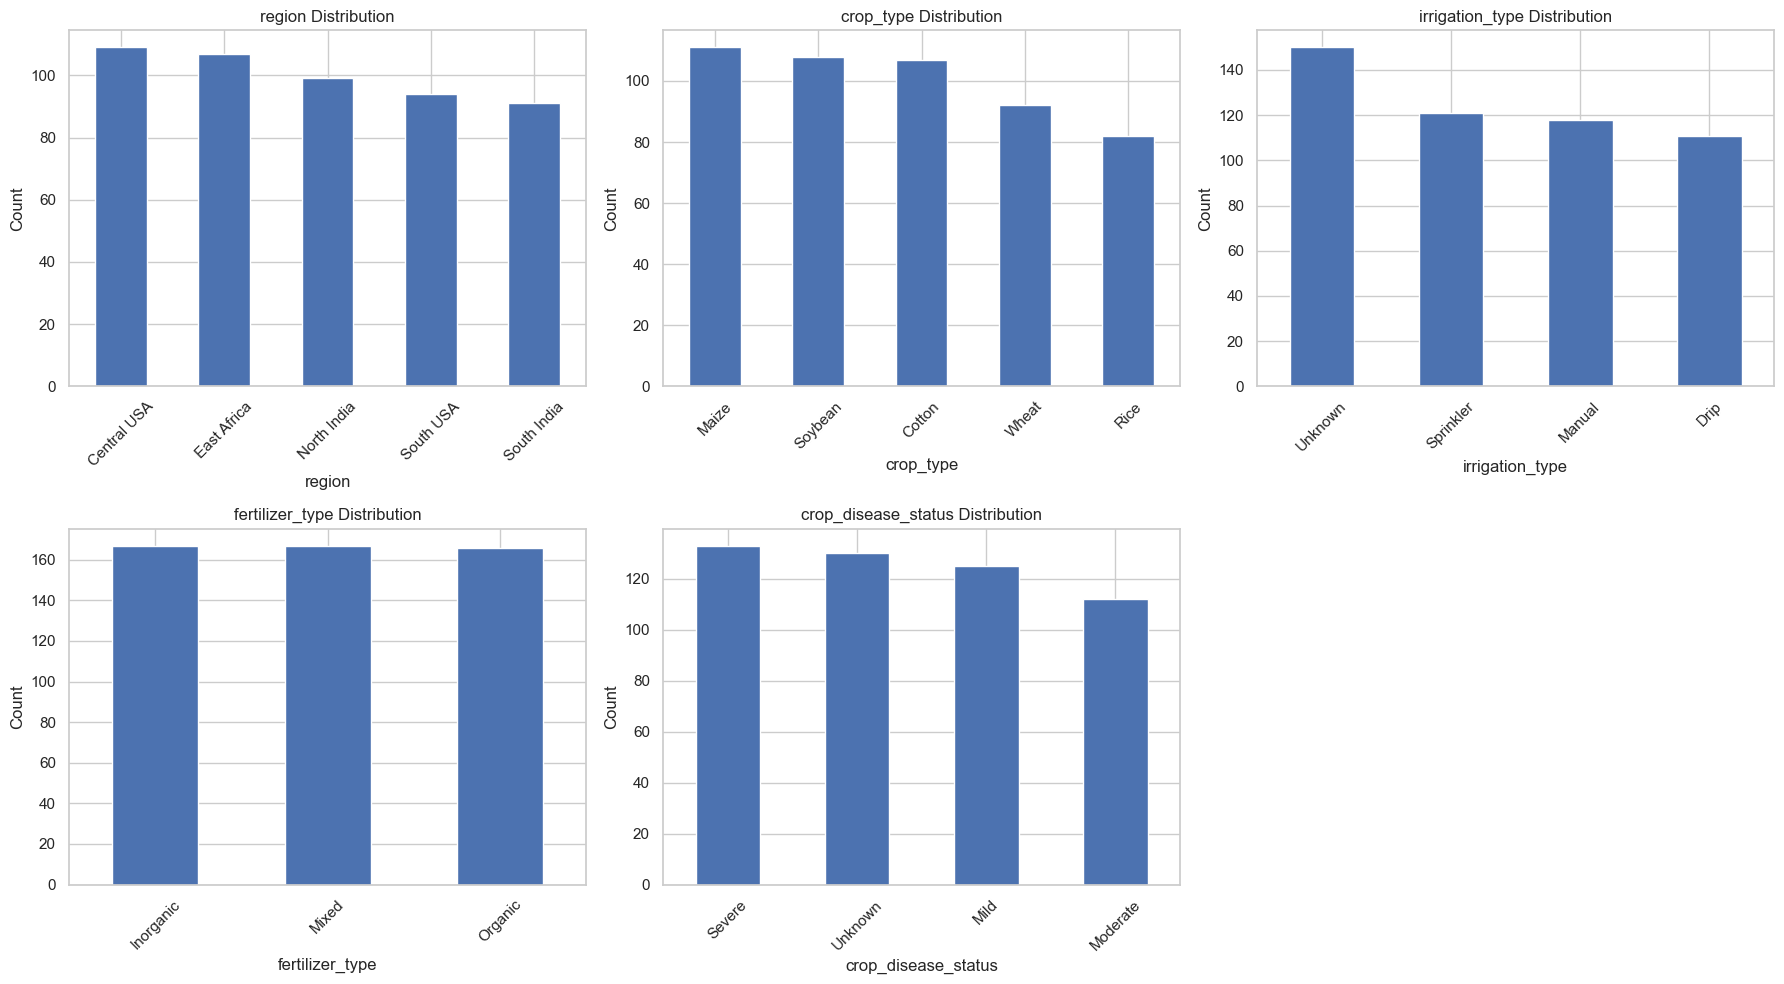

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    eda_df[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 7. Yield Analysis

In [33]:
yield_col = "yield_kg_per_hectare"
print("Yield statistics:")
display(eda_df[yield_col].describe().to_frame("Yield"))


Yield statistics:


,Yield
count,500.00
mean,4032.93
std,1174.43
min,2023.56
25%,2994.82
50%,4071.69
75%,5062.11
max,5998.29


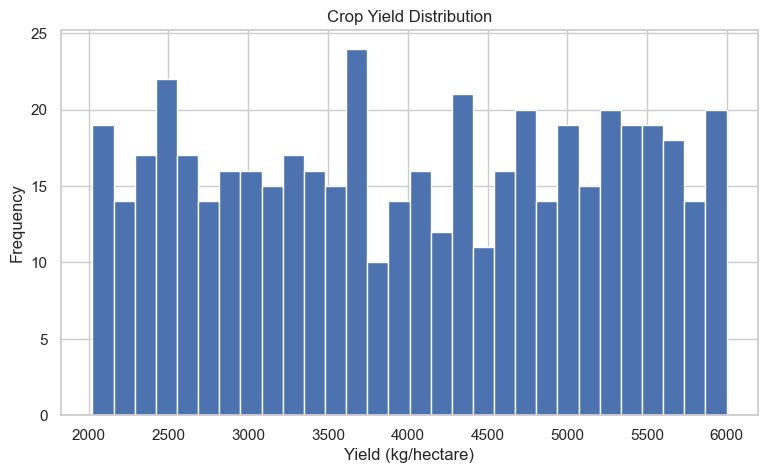

In [34]:
plt.figure(figsize=(9, 5))
plt.hist(eda_df[yield_col], bins=30)
plt.title("Crop Yield Distribution")
plt.xlabel("Yield (kg/hectare)")
plt.ylabel("Frequency")
plt.show()


## 8. Crop-wise Yield Analysis

In [35]:
crop_yield = (
    eda_df.groupby("crop_type")[yield_col]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)
display(crop_yield)


,count,mean,median,min,max
crop_type,,,,,
Soybean,108,4256.81,4387.39,2029.16,5998.29
Wheat,92,4077.58,3975.31,2043.13,5893.78
Maize,111,3982.55,3967.84,2023.56,5953.33
Cotton,107,3925.60,3774.90,2046.41,5980.83
Rice,82,3896.18,3934.32,2066.90,5952.62


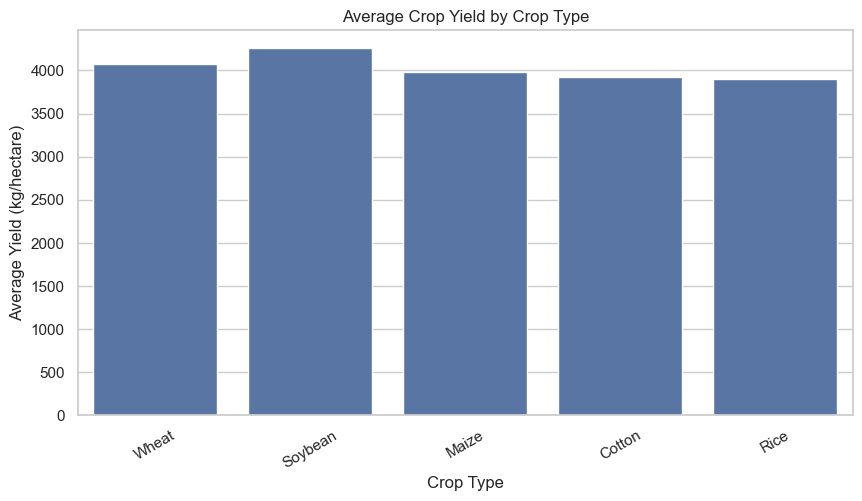

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(data=eda_df, x="crop_type", y=yield_col, estimator="mean", errorbar=None)
plt.title("Average Crop Yield by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=30)
plt.show()


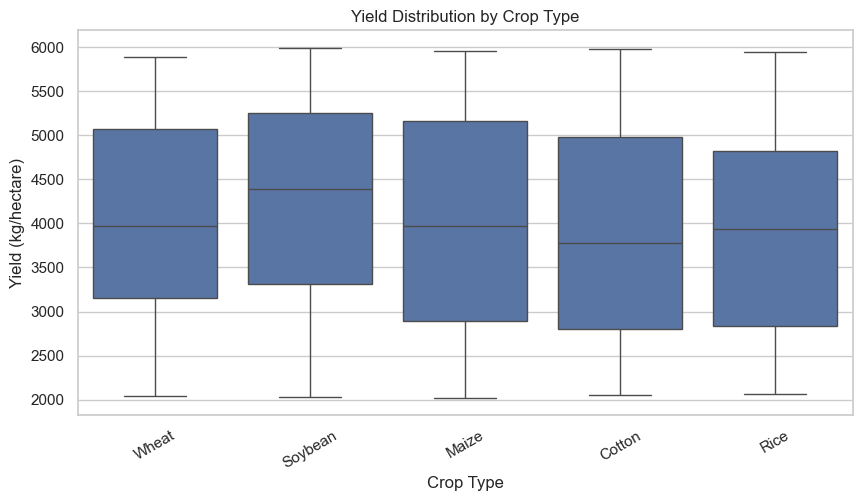

In [37]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_df, x="crop_type", y=yield_col)
plt.title("Yield Distribution by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Yield (kg/hectare)")
plt.xticks(rotation=30)
plt.show()


## 9. Environmental Factors vs. Yield

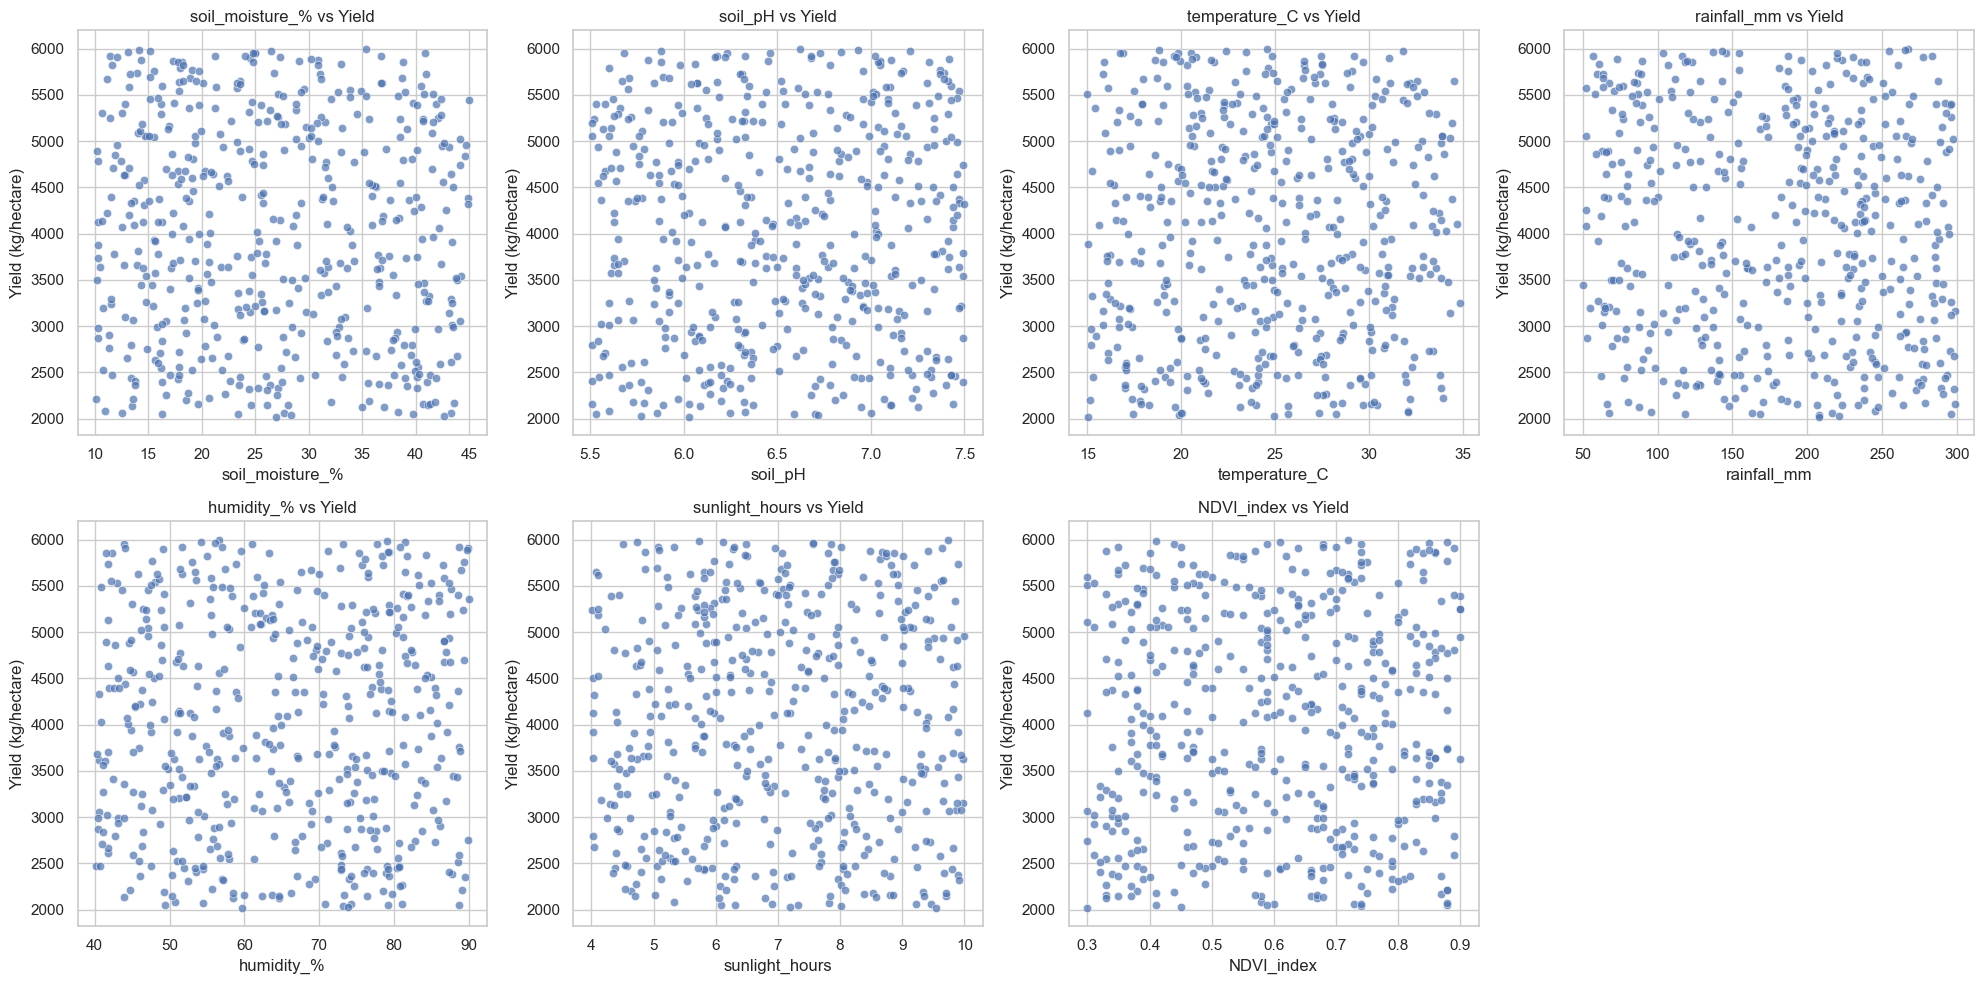

In [38]:
environmental_cols = [
    "soil_moisture_%", "soil_pH", "temperature_C",
    "rainfall_mm", "humidity_%", "sunlight_hours", "NDVI_index"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(environmental_cols):
    sns.scatterplot(data=eda_df, x=col, y=yield_col, ax=axes[i], alpha=0.7)
    axes[i].set_title(f"{col} vs Yield")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Yield (kg/hectare)")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 10. Irrigation and Fertilizer Analysis

,Average Yield
irrigation_type,
Sprinkler,4084.41
Manual,4070.09
Drip,4019.45
Unknown,3972.13


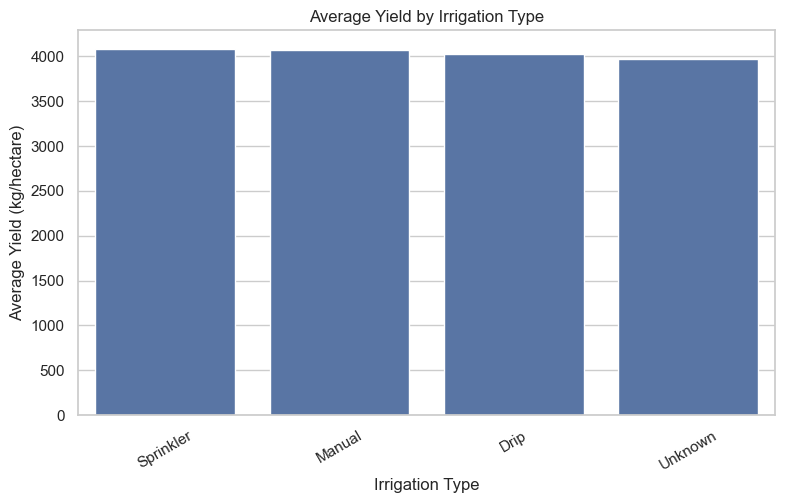

In [39]:
irrigation_yield = (
    eda_df.groupby("irrigation_type")[yield_col]
    .mean()
    .sort_values(ascending=False)
)
display(irrigation_yield.to_frame("Average Yield"))

plt.figure(figsize=(9, 5))
sns.barplot(x=irrigation_yield.index, y=irrigation_yield.values, errorbar=None)
plt.title("Average Yield by Irrigation Type")
plt.xlabel("Irrigation Type")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=30)
plt.show()


,Average Yield
fertilizer_type,
Inorganic,4087.12
Organic,4039.28
Mixed,3972.41


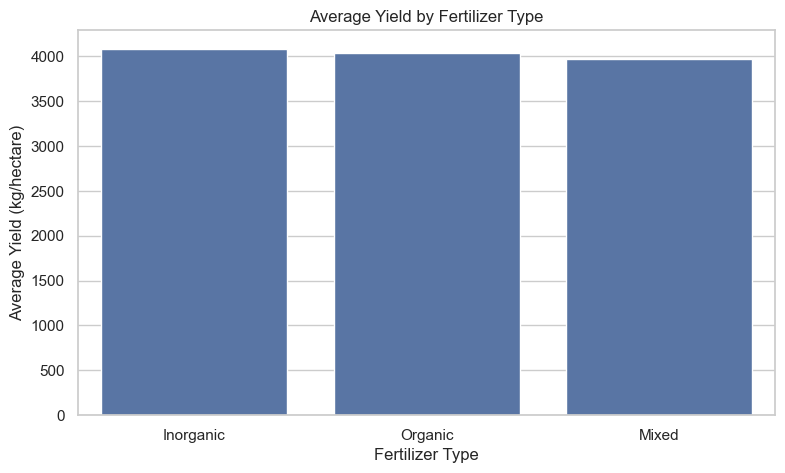

In [40]:
fertilizer_yield = (
    eda_df.groupby("fertilizer_type")[yield_col]
    .mean()
    .sort_values(ascending=False)
)
display(fertilizer_yield.to_frame("Average Yield"))

plt.figure(figsize=(9, 5))
sns.barplot(x=fertilizer_yield.index, y=fertilizer_yield.values, errorbar=None)
plt.title("Average Yield by Fertilizer Type")
plt.xlabel("Fertilizer Type")
plt.ylabel("Average Yield (kg/hectare)")
plt.show()


## 11. Correlation Heatmap

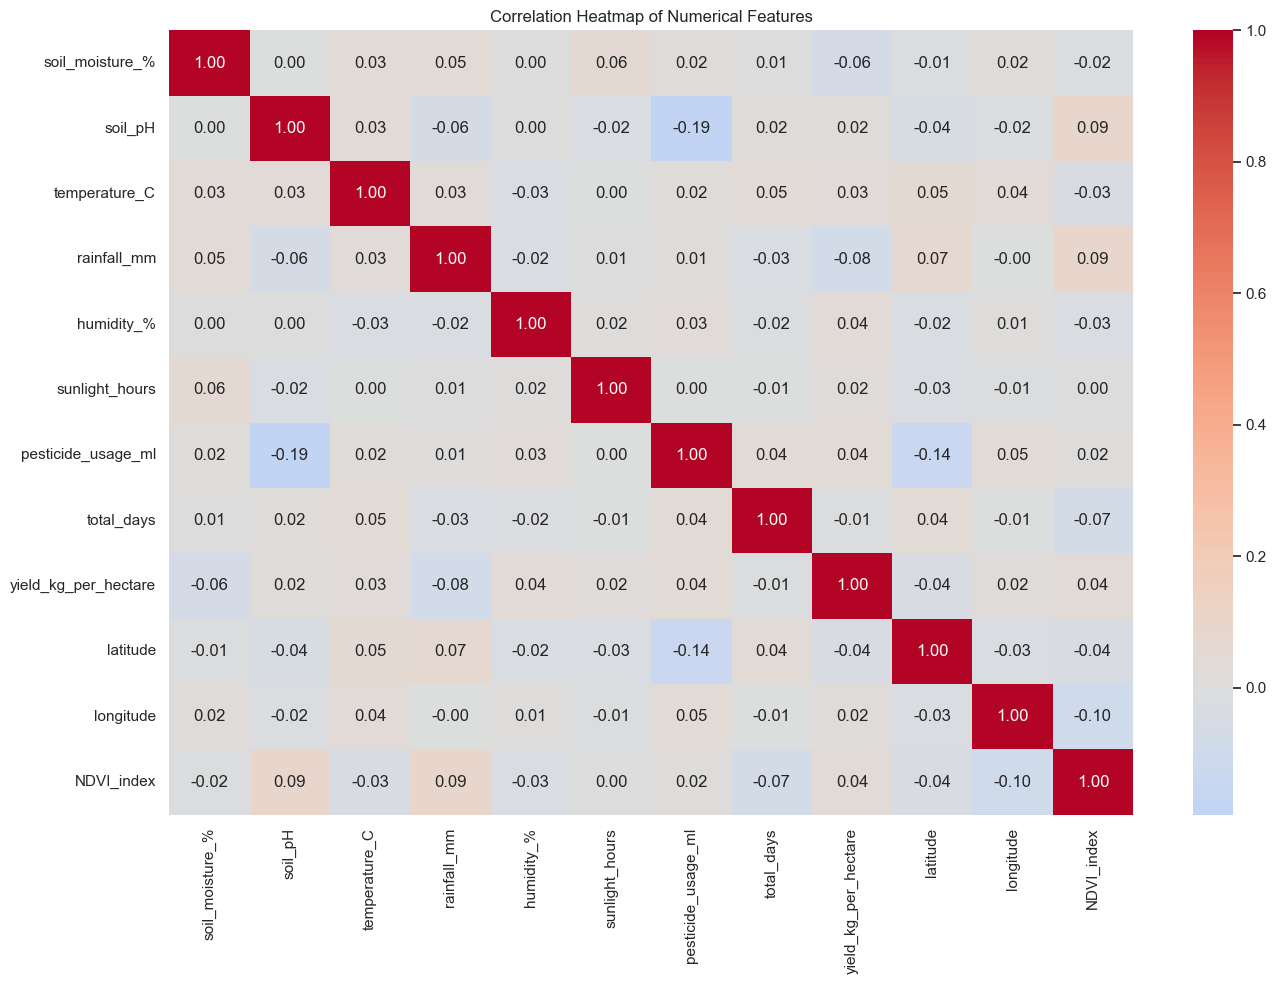

In [41]:
numeric_cols = eda_df.select_dtypes(include=np.number).columns
corr = eda_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


## 12. Features Most Correlated with Yield

In [42]:
yield_corr = (
    corr[yield_col]
    .drop(yield_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(yield_corr.to_frame("Correlation with Yield"))


,Correlation with Yield
rainfall_mm,-0.08
soil_moisture_%,-0.06
pesticide_usage_ml,0.04
humidity_%,0.04
latitude,-0.04
NDVI_index,0.04
temperature_C,0.03
soil_pH,0.02
longitude,0.02
sunlight_hours,0.02


## 13. Outlier Detection

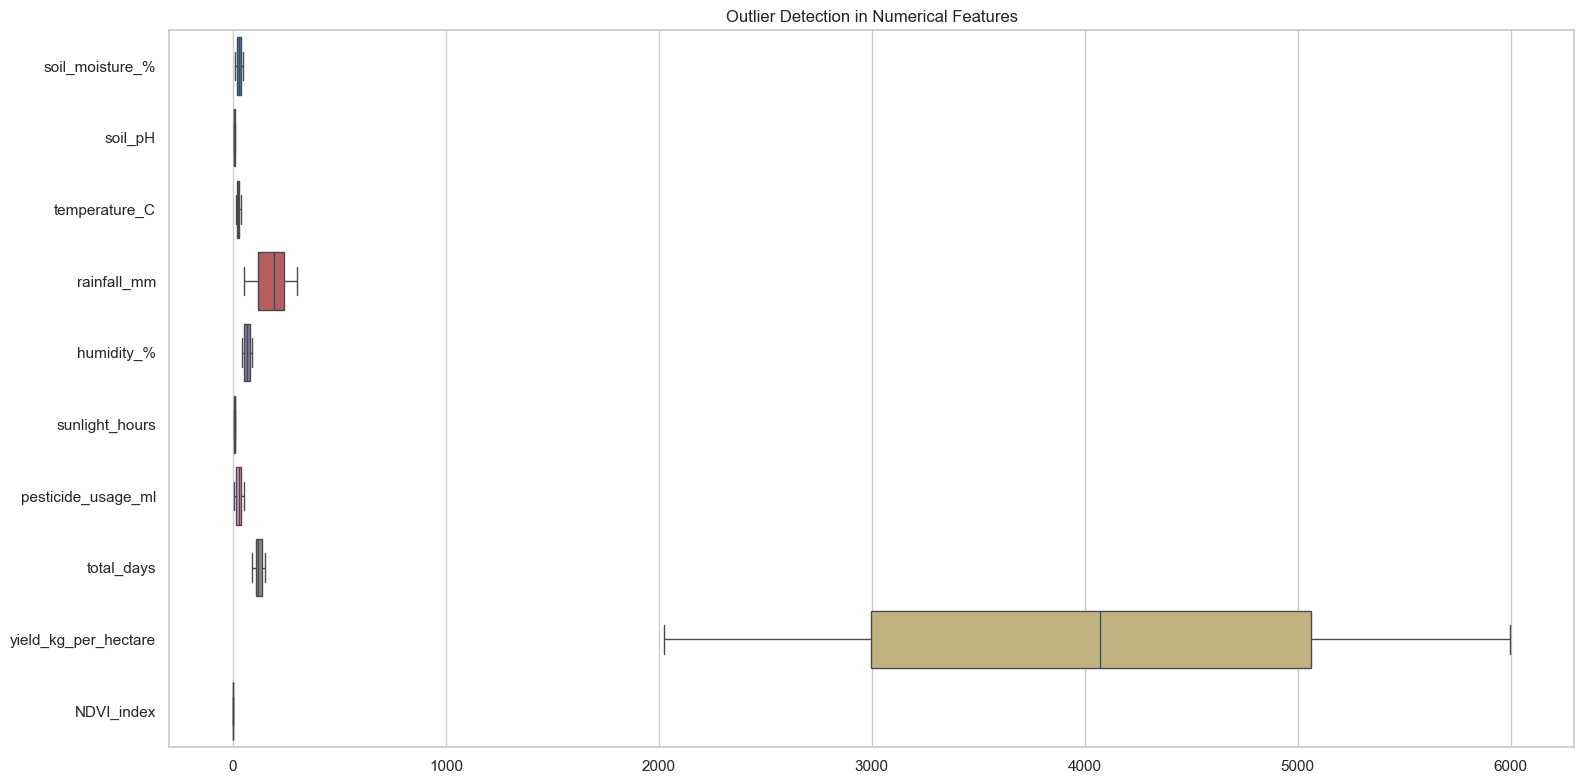

In [43]:
outlier_cols = [
    "soil_moisture_%", "soil_pH", "temperature_C",
    "rainfall_mm", "humidity_%", "sunlight_hours",
    "pesticide_usage_ml", "total_days",
    "yield_kg_per_hectare", "NDVI_index"
]

plt.figure(figsize=(16, 8))
sns.boxplot(data=eda_df[outlier_cols], orient="h")
plt.title("Outlier Detection in Numerical Features")
plt.tight_layout()
plt.show()


## 14. Date and Duration Analysis

In [44]:
eda_df["sowing_date"] = pd.to_datetime(eda_df["sowing_date"], errors="coerce")
eda_df["harvest_date"] = pd.to_datetime(eda_df["harvest_date"], errors="coerce")
eda_df["timestamp"] = pd.to_datetime(eda_df["timestamp"], errors="coerce")

print("Sowing date range:", eda_df["sowing_date"].min(), "to", eda_df["sowing_date"].max())
print("Harvest date range:", eda_df["harvest_date"].min(), "to", eda_df["harvest_date"].max())

display(eda_df["total_days"].describe().to_frame("Total Growing Days"))


Sowing date range: 2024-01-01 00:00:00 to 2024-03-28 00:00:00
Harvest date range: 2024-04-09 00:00:00 to 2024-08-17 00:00:00


,Total Growing Days
count,500.00
mean,119.50
std,16.80
min,90.00
25%,105.75
50%,119.00
75%,134.00
max,150.00


## 15. Key Findings

After running the notebook, update this section with the exact observations from the tables and graphs.

Suggested findings:
1. The dataset contains **500 records and 22 features**.
2. There are no duplicate rows in the original dataset.
3. Missing values are present mainly in `irrigation_type` and `crop_disease_status`.
4. Crop types, regions, irrigation methods, and fertilizer types have different distributions.
5. Yield varies across crop types.
6. Environmental features such as rainfall, temperature, humidity, soil moisture, sunlight, and NDVI can be compared with yield.
7. Correlation analysis helps identify numerical features that may be useful for crop-yield prediction.
8. Outlier analysis helps identify unusual agricultural/environmental observations.

**Important:** Do not claim that a feature strongly affects yield unless the graphs/correlation results support that conclusion.


## 16. EDA Conclusion

The dataset was explored using data-quality checks, statistical analysis, categorical analysis, visualizations, correlation analysis, and outlier detection.

The EDA results provide a foundation for **feature engineering and machine learning models for crop-yield prediction**.
